## 03 — Modélisation

— Chargement :

In [2]:
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

df_features = pd.read_csv(
    "/content/drive/MyDrive/PFE_Trafic/data/df_features.csv",
    parse_dates=["date"]
)
print("Données chargées :", df_features.shape)
df_features.head()

Mounted at /content/drive
Données chargées : (536000, 9)


,Page,date,views,lag_1,lag_7,lag_14,mean_7,day_of_week,month
0,15._November_de.wikipedia.org_desktop_all-agents,2015-07-15,27.0,21.0,27.0,32.0,30.142857,2,7
1,15._November_de.wikipedia.org_desktop_all-agents,2015-07-16,20.0,27.0,19.0,26.0,30.142857,3,7
2,15._November_de.wikipedia.org_desktop_all-agents,2015-07-17,23.0,20.0,21.0,22.0,30.285714,4,7
3,15._November_de.wikipedia.org_desktop_all-agents,2015-07-18,23.0,23.0,21.0,22.0,30.571429,5,7
4,15._November_de.wikipedia.org_desktop_all-agents,2015-07-19,27.0,23.0,64.0,29.0,30.857143,6,7


 Séparation train/test :

In [3]:
# On coupe dans le temps : derniers 60 jours = test
cutoff = df_features.groupby("Page")["date"].transform(
    lambda x: x.sort_values().iloc[-60]
)

train = df_features[df_features["date"] < cutoff].copy()
test  = df_features[df_features["date"] >= cutoff].copy()

print("Exemples train :", len(train))
print("Exemples test  :", len(test))
print("Ratio test     :", round(100 * len(test) / len(df_features), 1), "%")

Exemples train : 476000
Exemples test  : 60000
Ratio test     : 11.2 %


## Modèle 1 — Baseline 

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Baseline : prédire que demain = aujourd'hui (lag_1) ──────
test["pred_baseline"] = test["lag_1"]

mae_baseline  = mean_absolute_error(test["views"], test["pred_baseline"])
rmse_baseline = np.sqrt(mean_squared_error(test["views"], test["pred_baseline"]))

print("=== Modèle Baseline (lag_1) ===")
print(f"MAE  : {mae_baseline:.2f}")
print(f"RMSE : {rmse_baseline:.2f}")

=== Modèle Baseline (lag_1) ===
MAE  : 340.52
RMSE : 4170.12


## Modèle 2 — XGBoost

In [5]:
from xgboost import XGBRegressor

# Features et cible
features = ["lag_1", "lag_7", "lag_14", "mean_7", "day_of_week", "month"]
X_train = train[features]
y_train = train["views"]
X_test  = test[features]
y_test  = test["views"]

# Entraînement
model_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbosity=0
)
model_xgb.fit(X_train, y_train)

# Prédiction et évaluation
y_pred_xgb = model_xgb.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("=== XGBoost ===")
print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"\nAmélioration MAE  vs Baseline : {round(100*(mae_baseline-mae_xgb)/mae_baseline, 1)}%")
print(f"Amélioration RMSE vs Baseline : {round(100*(rmse_baseline-rmse_xgb)/rmse_baseline, 1)}%")

=== XGBoost ===
MAE  : 352.13
RMSE : 4060.72

Amélioration MAE  vs Baseline : -3.4%
Amélioration RMSE vs Baseline : 2.6%


In [6]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

features = ["lag_1", "lag_7", "lag_14", "mean_7", "day_of_week", "month"]
X_train, X_test = train[features], test[features]
y_train, y_test = train["views"], test["views"]

# Transformation log (log1p = log(1+x) pour gérer les zéros)
y_train_log = np.log1p(y_train)

model_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbosity=0
)
model_xgb.fit(X_train, y_train_log)

# Prédiction → retour à l'échelle originale (expm1 = inverse de log1p)
y_pred_xgb = np.expm1(model_xgb.predict(X_test))

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("=== XGBoost (avec log transform) ===")
print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"\nAmélioration MAE  vs Baseline : {round(100*(mae_baseline-mae_xgb)/mae_baseline, 1)}%")
print(f"Amélioration RMSE vs Baseline : {round(100*(rmse_baseline-rmse_xgb)/rmse_baseline, 1)}%")

=== XGBoost (avec log transform) ===
MAE  : 313.45
RMSE : 4312.09

Amélioration MAE  vs Baseline : 7.9%
Amélioration RMSE vs Baseline : -3.4%


In [7]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)
model_dt.fit(X_train, y_train_log)
y_pred_dt = np.expm1(model_dt.predict(X_test))

mae_dt  = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("=== Decision Tree ===")
print(f"MAE  : {mae_dt:.2f}")
print(f"RMSE : {rmse_dt:.2f}")
print(f"Amélioration MAE vs Baseline : {round(100*(mae_baseline-mae_dt)/mae_baseline, 1)}%")
print(f"\nXGBoost vs Decision Tree (MAE) : {'XGBoost' if mae_xgb < mae_dt else 'Decision Tree'} gagne")

=== Decision Tree ===
MAE  : 344.81
RMSE : 4547.81
Amélioration MAE vs Baseline : -1.3%

XGBoost vs Decision Tree (MAE) : XGBoost gagne


## Modèle 3 — Random Forest

In [8]:
from sklearn.ensemble import RandomForestRegressor

# Même setup que XGBoost
y_train_log = np.log1p(y_train)

model_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train, y_train_log)

y_pred_rf = np.expm1(model_rf.predict(X_test))

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("=== Random Forest ===")
print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"\nAmélioration MAE  vs Baseline : {round(100*(mae_baseline-mae_rf)/mae_baseline, 1)}%")
print(f"Amélioration RMSE vs Baseline : {round(100*(rmse_baseline-rmse_rf)/rmse_baseline, 1)}%")
print(f"\nDecision Tree vs Random Forest (MAE) : {'Decision Tree' if mae_dt < mae_rf else 'Random Forest'} gagne")

=== Random Forest ===
MAE  : 289.69
RMSE : 4002.83

Amélioration MAE  vs Baseline : 14.9%
Amélioration RMSE vs Baseline : 4.0%

Decision Tree vs Random Forest (MAE) : Random Forest gagne


## Modèle 5 — LSTM (Deep Learning)

Cellule 1 — Construction des séquences :

In [9]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEQ_LEN = 14

def build_sequences(df, seq_len):
    X, y = [], []
    for page, group in df.groupby("Page"):
        vals = np.log1p(group.sort_values("date")["views"].values)
        for i in range(seq_len, len(vals)):
            X.append(vals[i-seq_len:i])
            y.append(vals[i])
    return np.array(X).reshape(-1, seq_len, 1), np.array(y)

print("Séquences train...")
X_lstm_train, y_lstm_train = build_sequences(train, SEQ_LEN)
print("Séquences test...")
X_lstm_test,  y_lstm_test  = build_sequences(test,  SEQ_LEN)

print(f"Train : {X_lstm_train.shape}")
print(f"Test  : {X_lstm_test.shape}")

Séquences train...
Séquences test...
Train : (462000, 14, 1)
Test  : (46000, 14, 1)


Cellule 2 — Architecture :

In [10]:
model_lstm = Sequential([
    LSTM(64, input_shape=(SEQ_LEN, 1), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])
model_lstm.compile(optimizer="adam", loss="mse")
model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Cellule 3 — Entraînement :

In [11]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_lstm_train, y_lstm_train,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print("Entraînement terminé !")

Epoch 1/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 55s 32ms/step - loss: 0.4335 - val_loss: 0.2999
Epoch 2/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 83s 33ms/step - loss: 0.2577 - val_loss: 0.2599
Epoch 3/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 50s 31ms/step - loss: 0.2382 - val_loss: 0.2455
Epoch 4/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 53s 33ms/step - loss: 0.2283 - val_loss: 0.2334
Epoch 5/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 50s 31ms/step - loss: 0.2224 - val_loss: 0.2101
Epoch 6/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - loss: 0.2173 - val_loss: 0.2127
Epoch 7/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 53s 32ms/step - loss: 0.2140 - val_loss: 0.2627
Epoch 8/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - loss: 0.2124 - val_loss: 0.3112
Epoch 9/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 50s 31ms/step - loss: 0.2103 - val_loss: 0.2545
Epoch 10/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - loss: 0.2088 - val_loss: 0.2942
Entraînement terminé !


Cellule 4 — Évaluation :

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_lstm = np.expm1(model_lstm.predict(X_lstm_test).flatten())
y_true_lstm = np.expm1(y_lstm_test)

mae_lstm  = mean_absolute_error(y_true_lstm, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_true_lstm, y_pred_lstm))

print("=== LSTM (séquences 14 jours) ===")
print(f"MAE  : {mae_lstm:.2f}")
print(f"RMSE : {rmse_lstm:.2f}")
print(f"\nAmélioration MAE vs Baseline : {round(100*(mae_baseline-mae_lstm)/mae_baseline, 1)}%")
print(f"LSTM vs Random Forest        : {'LSTM' if mae_lstm < mae_rf else 'Random Forest'} gagne")

1438/1438 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
=== LSTM (séquences 14 jours) ===
MAE  : 281.09
RMSE : 4328.74

Amélioration MAE vs Baseline : 17.5%
LSTM vs Random Forest        : LSTM gagne


## Modèle 6 — GRU (Deep Learning)

Cellule 1 — Architecture GRU :

In [13]:
from tensorflow.keras.layers import GRU

model_gru = Sequential([
    GRU(64, input_shape=(SEQ_LEN, 1), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])
model_gru.compile(optimizer="adam", loss="mse")
model_gru.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

Cellule 2 — Entraînement GRU :

In [14]:
early_stop_gru = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_gru = model_gru.fit(
    X_lstm_train, y_lstm_train,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop_gru],
    verbose=1
)
print("Entraînement GRU terminé !")

Epoch 1/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 63s 37ms/step - loss: 0.4372 - val_loss: 0.2540
Epoch 2/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 60s 37ms/step - loss: 0.2563 - val_loss: 0.2455
Epoch 3/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - loss: 0.2339 - val_loss: 0.2092
Epoch 4/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 61s 37ms/step - loss: 0.2254 - val_loss: 0.2137
Epoch 5/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 60s 37ms/step - loss: 0.2207 - val_loss: 0.2143
Epoch 6/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 64s 39ms/step - loss: 0.2174 - val_loss: 0.2151
Epoch 7/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 62s 38ms/step - loss: 0.2152 - val_loss: 0.2132
Epoch 8/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - loss: 0.2129 - val_loss: 0.2047
Epoch 9/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 61s 37ms/step - loss: 0.2110 - val_loss: 0.2440
Epoch 10/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - loss: 0.2098 - val_loss: 0.2594
Epoch 11/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 61s 38ms/step - loss: 0.2083 - val_loss: 0.2372
Epoch 12

Cellule 3 — Évaluation GRU :

In [15]:
y_pred_gru = np.expm1(model_gru.predict(X_lstm_test).flatten())
y_true_gru = np.expm1(y_lstm_test)

mae_gru  = mean_absolute_error(y_true_gru, y_pred_gru)
rmse_gru = np.sqrt(mean_squared_error(y_true_gru, y_pred_gru))

print("=== GRU ===")
print(f"MAE  : {mae_gru:.2f}")
print(f"RMSE : {rmse_gru:.2f}")
print(f"\nAmélioration MAE vs Baseline : {round(100*(mae_baseline-mae_gru)/mae_baseline, 1)}%")
print(f"GRU vs LSTM : {'GRU' if mae_gru < mae_lstm else 'LSTM'} gagne")

1438/1438 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
=== GRU ===
MAE  : 281.15
RMSE : 4415.60

Amélioration MAE vs Baseline : 17.4%
GRU vs LSTM : LSTM gagne


## Volet Détection d'anomalies
### Méthode 1 — Z-score

=== Détection Z-score ===
Seuil utilisé       : z > 3
Anomalies détectées : 111
Pourcentage         : 0.24%


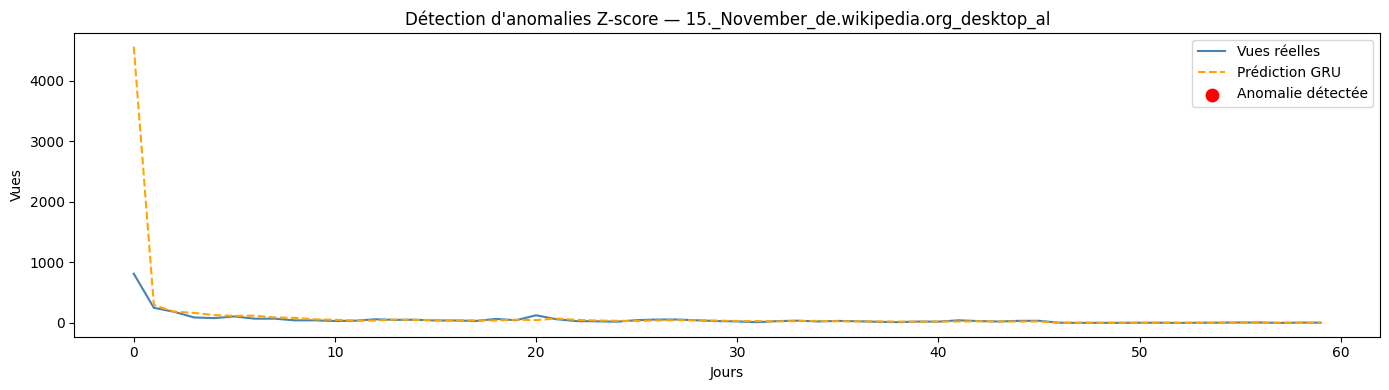

In [16]:
import matplotlib.pyplot as plt

# ── Z-score sur les résidus du meilleur modèle (GRU) ───────
# Un résidu = différence entre valeur réelle et prédiction
# Si le résidu est très grand → anomalie

# On travaille sur le test set
residus = np.abs(y_true_gru - y_pred_gru)

# Z-score : (valeur - moyenne) / écart-type
mean_res = np.mean(residus)
std_res  = np.std(residus)
z_scores = (residus - mean_res) / std_res

# Seuil : z > 3 = anomalie (règle statistique classique)
SEUIL = 3
anomalies_zscore = z_scores > SEUIL

print("=== Détection Z-score ===")
print(f"Seuil utilisé       : z > {SEUIL}")
print(f"Anomalies détectées : {anomalies_zscore.sum()}")
print(f"Pourcentage         : {100*anomalies_zscore.mean():.2f}%")

# Visualisation sur une page exemple
page_ex = test["Page"].unique()[0]
mask    = test["Page"].values[:len(y_true_gru)] == page_ex

plt.figure(figsize=(14, 4))
plt.plot(y_true_gru[mask], label="Vues réelles", color="steelblue")
plt.plot(y_pred_gru[mask], label="Prédiction GRU", color="orange", linestyle="--")
idx_anom = np.where(anomalies_zscore[mask])[0]
plt.scatter(idx_anom,
            y_true_gru[mask][idx_anom],
            color="red", zorder=5, label="Anomalie détectée", s=80)
plt.title(f"Détection d'anomalies Z-score — {page_ex[:40]}")
plt.xlabel("Jours"); plt.ylabel("Vues")
plt.legend(); plt.tight_layout()
plt.savefig("anomalies_zscore.png", dpi=120)
plt.show()

### Méthode 2 — Isolation Forest

=== Isolation Forest ===
Anomalies détectées : 137
Pourcentage         : 0.30%

Anomalies détectées par les DEUX méthodes : 0
→ Ces 0 jours sont très probablement de vraies anomalies


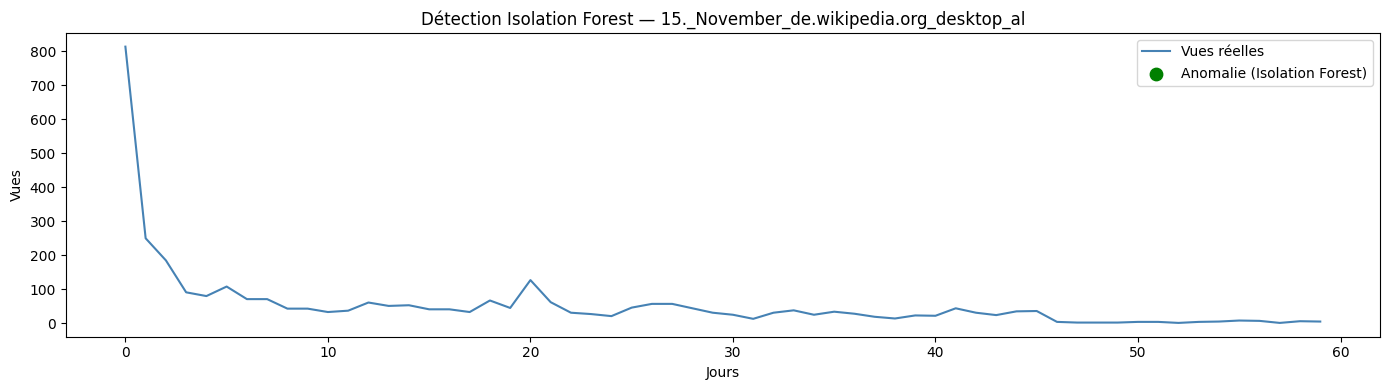

In [17]:
from sklearn.ensemble import IsolationForest

# Isolation Forest travaille directement sur les features
# On utilise les vues réelles + lag_1 comme contexte
X_anomaly = test[["views", "lag_1", "mean_7"]].values[:len(y_true_gru)]

model_if = IsolationForest(
    contamination=0.003,  # on s'attend à ~0.3% d'anomalies
    random_state=42,
    n_estimators=100
)
model_if.fit(X_anomaly)
predictions_if = model_if.predict(X_anomaly)

# Isolation Forest retourne -1 pour anomalie, 1 pour normal
anomalies_if = predictions_if == -1

print("=== Isolation Forest ===")
print(f"Anomalies détectées : {anomalies_if.sum()}")
print(f"Pourcentage         : {100*anomalies_if.mean():.2f}%")

# Comparaison avec Z-score
commun = anomalies_zscore & anomalies_if
print(f"\nAnomalies détectées par les DEUX méthodes : {commun.sum()}")
print(f"→ Ces {commun.sum()} jours sont très probablement de vraies anomalies")

# Visualisation
page_ex = test["Page"].unique()[0]
mask    = test["Page"].values[:len(y_true_gru)] == page_ex

plt.figure(figsize=(14, 4))
plt.plot(y_true_gru[mask], label="Vues réelles", color="steelblue")
idx_if = np.where(anomalies_if[mask])[0]
plt.scatter(idx_if,
            y_true_gru[mask][idx_if],
            color="green", zorder=5, label="Anomalie (Isolation Forest)", s=80)
plt.title(f"Détection Isolation Forest — {page_ex[:40]}")
plt.xlabel("Jours"); plt.ylabel("Vues")
plt.legend(); plt.tight_layout()
plt.savefig("anomalies_isolation_forest.png", dpi=120)
plt.show()

## Évaluation comparative — Tous les modèles

Modèle             Type            MAE       RMSE  vs Baseline
Baseline           Référence    340.52    4170.12         0.0%
Decision Tree      ML           344.81    4547.81        -1.3%
XGBoost            ML           313.45    4312.09        +7.9%
LSTM               DL           281.09    4328.74       +17.5%
Random Forest      ML           289.69    4002.83       +14.9%
GRU                DL           281.15    4415.60       +17.4%

🥇 Meilleur modèle (MAE) : LSTM


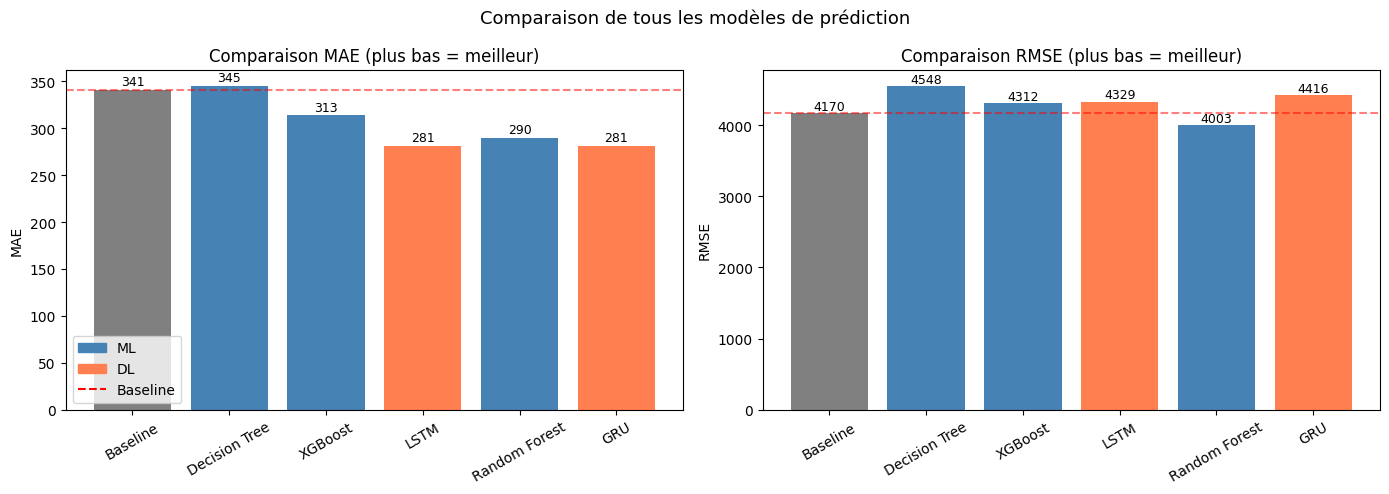

Graphique sauvegardé.


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ── Tableau récapitulatif ────────────────────────────────────
modeles = ["Baseline", "Decision Tree", "XGBoost", "LSTM", "Random Forest", "GRU"]
maes    = [mae_baseline,   mae_dt,          mae_xgb,   mae_lstm, mae_rf,         mae_gru]
rmses   = [rmse_baseline,  rmse_dt,         rmse_xgb,  rmse_lstm, rmse_rf,        rmse_gru]
types   = ["Référence","ML",            "ML",       "DL",     "ML",           "DL"]

print("="*65)
print(f"{'Modèle':<18} {'Type':<10} {'MAE':>8} {'RMSE':>10} {'vs Baseline':>12}")
print("="*65)
for m, t, mae, rmse in zip(modeles, types, maes, rmses):
    amelio = round(100*(mae_baseline - mae)/mae_baseline, 1)
    signe  = "+" if amelio > 0 else ""
    print(f"{m:<18} {t:<10} {mae:>8.2f} {rmse:>10.2f} {signe+str(amelio)+'%':>12}")
print("="*65)
print(f"\n🥇 Meilleur modèle (MAE) : {modeles[np.argmin(maes)]}")

# ── Graphique 1 : MAE comparé ────────────────────────────────
colors = ["gray","steelblue","steelblue","coral","steelblue","coral"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(modeles, maes, color=colors)
axes[0].axhline(mae_baseline, color="red", linestyle="--", alpha=0.5, label="Baseline")
axes[0].set_title("Comparaison MAE (plus bas = meilleur)")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis='x', rotation=30)
for bar, mae in zip(bars, maes):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 f"{mae:.0f}", ha="center", va="bottom", fontsize=9)

# ── Graphique 2 : RMSE comparé ───────────────────────────────
bars2 = axes[1].bar(modeles, rmses, color=colors)
axes[1].axhline(rmse_baseline, color="red", linestyle="--", alpha=0.5, label="Baseline")
axes[1].set_title("Comparaison RMSE (plus bas = meilleur)")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis='x', rotation=30)
for bar, rmse in zip(bars2, rmses):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 f"{rmse:.0f}", ha="center", va="bottom", fontsize=9)

from matplotlib.patches import Patch
legend = [Patch(color="steelblue", label="ML"), Patch(color="coral", label="DL")]
axes[0].legend(handles=legend+[plt.Line2D([0],[0], color="red", linestyle="--", label="Baseline")])
plt.suptitle("Comparaison de tous les modèles de prédiction", fontsize=13)
plt.tight_layout()
plt.savefig("comparaison_modeles.png", dpi=120, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé.")

In [19]:
import shutil, os

# Créer dossier figures sur Drive
figures_path = "/content/drive/MyDrive/PFE_Trafic/figures"
os.makedirs(figures_path, exist_ok=True)

# Copier tous les graphiques
for fig in ["anomalies_zscore.png",
            "anomalies_isolation_forest.png",
            "comparaison_modeles.png",
            "preuve_representativite.png"]:
    if os.path.exists(fig):
        shutil.copy(fig, figures_path)
        print(f"Copié : {fig}")

print("Tous les graphiques sauvegardés sur Drive !")

Copié : anomalies_zscore.png
Copié : anomalies_isolation_forest.png
Copié : comparaison_modeles.png
Tous les graphiques sauvegardés sur Drive !


In [20]:
import joblib, os

os.makedirs("/content/drive/MyDrive/PFE_Trafic/models", exist_ok=True)

# Sauvegarder les modèles ML
joblib.dump(model_rf,  "/content/drive/MyDrive/PFE_Trafic/models/random_forest.joblib")
joblib.dump(model_xgb, "/content/drive/MyDrive/PFE_Trafic/models/xgboost.joblib")
joblib.dump(model_dt,  "/content/drive/MyDrive/PFE_Trafic/models/decision_tree.joblib")

# Sauvegarder le GRU
model_gru.save("/content/drive/MyDrive/PFE_Trafic/models/gru_model.keras")

# Charger df_petit (déjà sauvegardé depuis notebook 01)
import pandas as pd
df_petit = pd.read_csv("/content/drive/MyDrive/PFE_Trafic/data/df_petit.csv")

# Sauvegarder 20 pages pour la démo Streamlit
demo_pages = df_petit.sample(20, random_state=42)
demo_pages.to_csv("/content/drive/MyDrive/PFE_Trafic/models/demo_pages.csv", index=False)

print("Tous les modèles sauvegardés !")
print("demo_pages.csv :", len(demo_pages), "pages")

Tous les modèles sauvegardés !
demo_pages.csv : 20 pages


In [21]:
import os
print(os.getcwd())

/content
